# GradientEngine: Using AD for ptychography

For the interactive marimo version, open [01_cpm_tutorial.py](../demos/gradient_engine/01_cpm_tutorial.py). Noise comparisons are in [01_noise_models.py](../demos/gradient_engine/01_noise_models.py).

Open this notebook with PtyLab and PyTorch installed in your environment. Note that PyTorch must be separately installed.

Like [jupyter_tutorials_tutorial_CPM.ipynb](jupyter_tutorials_tutorial_CPM.ipynb), this tutorial simulates CPM
measurements and reconstructs an object and probe. The examples compare different engine configurations while using a single coherent object and probe, one wavelength, and one slice. Mixed-state reconstruction is not supported by GradientEngine yet.

Also note that the goal of this tutorial is not to show perfect reconstructions but different use cases of this work-in-progress module.

In [1]:
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

ITERATIONS = 100
BATCH_SIZE = 3
NUM_POSITIONS = 50  # The main CPM tutorial uses 100 positions.


## 1. Simulate data with the selected propagation model

Measurements are generated with PtyLab's operators. ASP needs equal sample and detector pixel spacing. Set that
spacing before creating the encoder coordinates and initializing the fields.

In [2]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve2d

from PtyLab import DummyMonitor, ExperimentalData, Params, Reconstruction
from PtyLab.Engines.GradientEngine import GradientEngine
from PtyLab.Operators.Operators import aspw, object2detector
from PtyLab.utils.scanGrids import GenerateNonUniformFermat
from PtyLab.utils.utils import cart2pol, circ, gaussian2D
from PtyLab.utils.visualisation import hsvplot


def simulate(propagator="Fraunhofer", detector_amplitude=1.0):
    """Return simulated CPM data, initial reconstruction, and the true spiral object."""
    np.random.seed(7)
    size = 128
    object_size = 512
    data = ExperimentalData(operationMode="CPM")
    data.wavelength = 632.8e-9
    data.zo = 0.05
    data.dxd = 16 * 4.5e-6
    sample_pixel = data.wavelength * data.zo / (size * data.dxd)
    reference_pixel = sample_pixel
    if propagator == "ASP":
        sample_pixel = data.dxd
    y, x = GenerateNonUniformFermat(NUM_POSITIONS, radius=100, power=1)
    # Include the original simulation's 50-pixel offset in the encoder too,
    # so simulated patches and reconstruction positions refer to the same area.
    data.encoder = (np.column_stack((y, x)) + 50) * sample_pixel
    data.ptychogram = np.ones((NUM_POSITIONS, size, size), dtype=np.float32)
    data.entrancePupilDiameter = 150e-6
    data.spectralDensity = None
    data.theta = None
    data._setData()

    params = Params()
    params.gpuSwitch = False  # Torch's device is configured on the engine.
    params.positionOrder = "sequential"
    params.propagator = propagator
    initial = Reconstruction(data, params)
    initial.dxp = sample_pixel
    initial.No = object_size
    initial.npsm = initial.nosm = initial.nlambda = initial.nslice = 1
    initial.initialObject = "ones"
    initial.initialProbe = "circ"
    initial.initializeObjectProbe()

    # Reproduce the spiral object and focused probe from
    # jupyter_tutorials_tutorial_CPM.ipynb.
    # Keep these arrays identical across propagators. For ASP the same sampled
    # pattern represents a larger physical area because its pixel spacing differs.
    xo = np.arange(-object_size // 2, object_size // 2) * reference_pixel
    Xo, Yo = np.meshgrid(xo, xo)
    theta, rho = cart2pol(Xo, Yo)
    spiral = (1 + np.sign(np.sin(33 * theta + 2 * np.pi * (rho / 1e-3) ** 2))) / 2
    spiral = spiral * circ(Xo, Yo, object_size * reference_pixel) * (
        1 - circ(Xo, Yo, 200 * reference_pixel)
    ) + circ(Xo, Yo, 130 * reference_pixel)
    true_object = convolve2d(spiral, gaussian2D(5, 3), mode="same")

    xp = np.arange(-size // 2, size // 2) * reference_pixel
    Xp, Yp = np.meshgrid(xp, xp)
    Lp = size * reference_pixel
    f = 5e-3
    pinhole = convolve2d(
        circ(Xp, Yp, Lp / 2), gaussian2D(5, 1).astype(np.float32), mode="same"
    )
    true_probe = aspw(pinhole, 2 * f, data.wavelength, Lp, is_FT=False)[0]
    aperture = convolve2d(
        circ(Xp, Yp, 3 * Lp / 4), gaussian2D(5, 3).astype(np.float32), mode="same"
    )
    true_probe *= (
        np.exp(-1j * 2 * np.pi / data.wavelength * (Xp**2 + Yp**2) / (2 * f)) * aperture
    )
    true_probe = aspw(true_probe, 2 * f, data.wavelength, Lp, is_FT=False)[0]
    for index, (row, col) in enumerate(initial.positions):
        patch = true_object[row : row + size, col : col + size]
        initial.esw = (patch * true_probe).reshape(1, 1, 1, 1, size, size)
        _, detector = object2detector(initial.esw, params, initial)
        data.ptychogram[index] = np.squeeze(abs(detector_amplitude * detector) ** 2)
    data._setData()
    initial.probe[...] = 0.85 * true_probe
    return data, initial, true_object


def make_engine(data: ExperimentalData, initial: Reconstruction) -> GradientEngine:
    """Create a configured GradientEngine with an independent copy of the guesses."""
    reconstruction = deepcopy(initial)
    engine = GradientEngine(reconstruction, data, reconstruction.params, DummyMonitor())
    engine.device = DEVICE
    engine.numIterations = ITERATIONS
    engine.batchSize = BATCH_SIZE
    return engine


# Each objective has its own scale; regularized losses include their penalty,
# and Poisson loss can be negative. Use separate linear-axis plots.
# Object/probe estimates have scale and phase ambiguities; unilluminated
# object pixels are unconstrained.
def show_result(name: str, reconstruction: Reconstruction):
    """Display the reconstructed object and objective immediately after a run."""
    history = np.asarray(reconstruction.error)
    if not np.isfinite(history).all():
        raise RuntimeError(f"Nonfinite objective in {name}")
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    fig.suptitle(name)
    hsvplot(reconstruction.object.squeeze(), ax=axes[0])
    axes[0].set_title("Object amplitude")
    axes[0].axis("off")
    axes[1].plot(history)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Own objective")
    fig.tight_layout()
    print(f"{name}: {history[0]:.5g} -> {history[-1]:.5g}")
    plt.show(block=False)
    plt.pause(0.01)  # Let GUI backends draw before the next reconstruction.

## 2. Swap the loss; keep the engine and simulated data

Assign a callable with signature (predicted_intensity, measured_intensity,
total_scan_power). It must return a scalar Torch loss summed over all input
frames, so batching does not change the objective. Learning rates may need
tuning when switching losses. This noiseless example demonstrates the API;
Poisson likelihood is also useful for photon-counting measurements.

INFO:GPU:cupy and CUDA available, switching to GPU
INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ
GradientEngine: 100%|██████████| 100/100 [00:01<00:00, 94.96it/s, loss=0.00283] 


Amplitude: 0.39043 -> 0.0028329


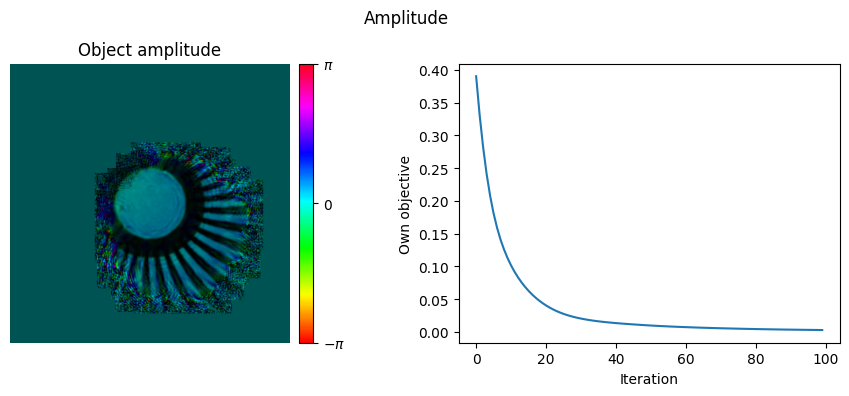

GradientEngine: 100%|██████████| 100/100 [00:00<00:00, 115.86it/s, loss=2.13e-6]


Intensity: 3.2114e-05 -> 2.1314e-06


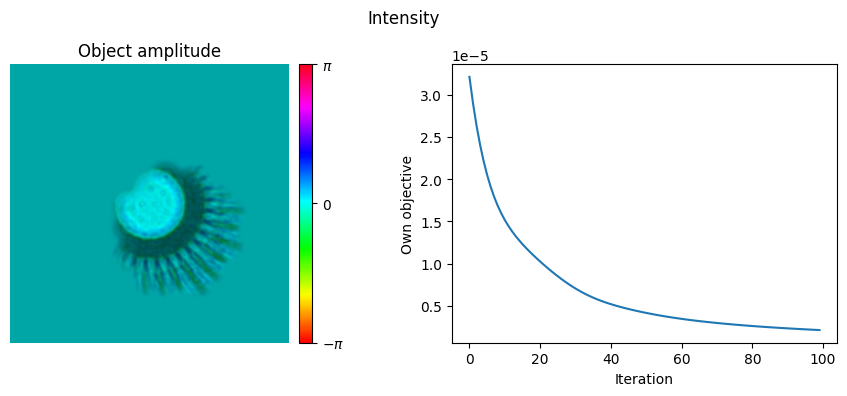

GradientEngine: 100%|██████████| 100/100 [00:00<00:00, 106.49it/s, loss=0.394]


Poisson: 1.0486 -> 0.39394


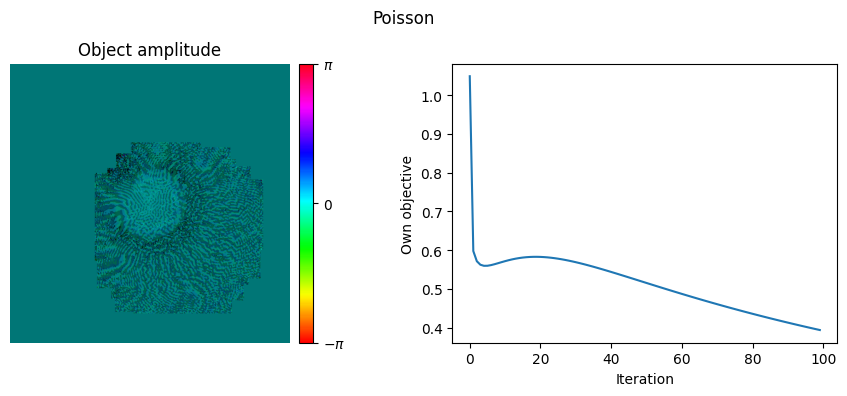

In [3]:
from PtyLab.Engines.GradientEngine.losses import (
    amplitude_loss,
    intensity_loss,
    poisson_loss,
)

data, initial, true_object = simulate()
results = {}
for name, loss_function in (
    ("Amplitude", amplitude_loss),
    ("Intensity", intensity_loss),
    ("Poisson", poisson_loss),
):
    engine = make_engine(data, initial)
    engine.lossFunction = loss_function
    engine.reconstruct()
    results[name] = engine.reconstruction
    show_result(name, engine.reconstruction)

## 3. Add an object regularizer

Penalties receive the complete model (access model.object and model.probe.field) and are applied once per
iteration. Set their weights with partial; keep their computations in Torch.

GradientEngine: 100%|██████████| 100/100 [00:01<00:00, 99.70it/s, loss=0.00294]


Amplitude + smoothness: 0.39043 -> 0.0029441


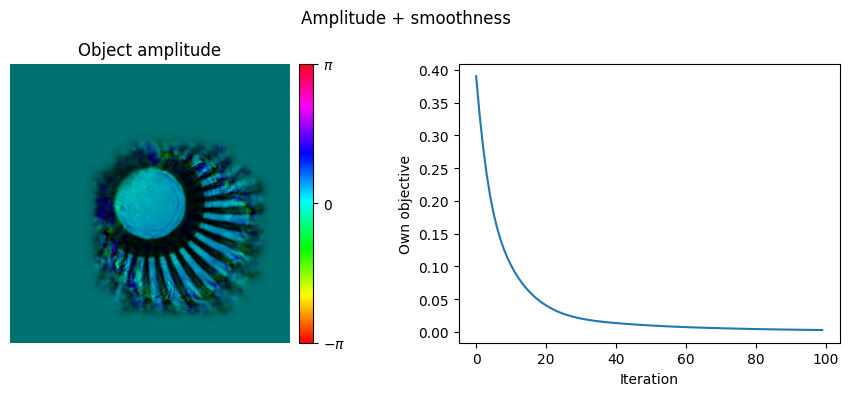

In [4]:
from functools import partial

from PtyLab.Engines.GradientEngine.regularizers import object_smoothness

engine = make_engine(data, initial)
engine.lossFunction = amplitude_loss
engine.regularizers = [partial(object_smoothness, weight=0.02)]
engine.reconstruct()
results["Amplitude + smoothness"] = engine.reconstruction
show_result("Amplitude + smoothness", engine.reconstruction)

## 4. Assign a custom forward model

The model owns the object and probe components and returns batched intensity.
A known efficiency multiplies predicted intensity directly. All batch sizes use
model(indices); additional registered parameters can be selected by name through
engine.parameters. No forwardBatch override is required.


INFO:GPU:cupy and CUDA available, switching to GPU
INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ
GradientEngine: 100%|██████████| 100/100 [00:00<00:00, 101.18it/s, loss=0.00283]


Known detector efficiency: 0.39043 -> 0.0028311


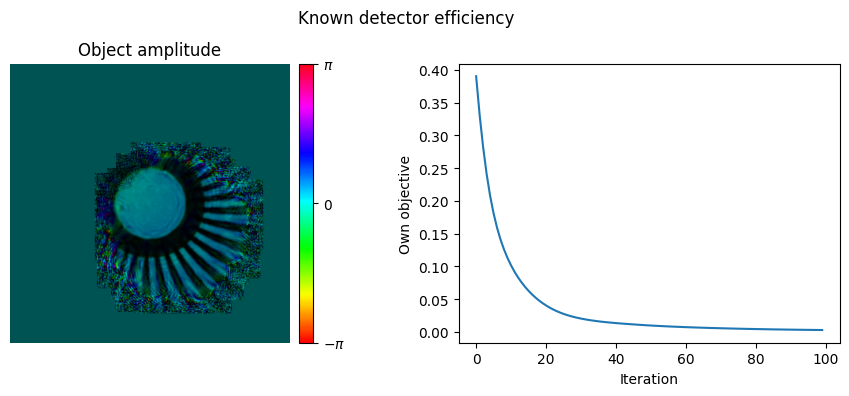

In [5]:
from PtyLab.Engines.GradientEngine import PtychographyModel, SharedProbe


class DetectorEfficiencyModel(PtychographyModel):
    def __init__(self, reconstruction, efficiency):
        super().__init__(
            reconstruction.object,
            SharedProbe(reconstruction.probe),
            reconstruction.positions,
        )
        self.register_buffer("efficiency", torch.tensor(float(efficiency)))

    def forward(self, indices):
        return self.efficiency * super().forward(indices)


efficiency = 0.7
custom_data, custom_initial, _ = simulate(detector_amplitude=np.sqrt(efficiency))
engine = make_engine(custom_data, custom_initial)
engine.model = DetectorEfficiencyModel(engine.reconstruction, efficiency)
engine.parameters = {"object": {"lr": 0.03}, "probe.field": {"lr": 0.01}}
engine.reconstruct()
results["Known detector efficiency"] = engine.reconstruction
show_result("Known detector efficiency", engine.reconstruction)


## 5. Select a built-in propagator

`preparePropagation()` builds `KernelPropagator` from `params.propagator` on each
run. Regenerate the measurements for each geometry. Arbitrary propagation
callables currently require overriding `preparePropagation()` in a subclass;
assigning `engine.propagation` before `reconstruct()` would be overwritten.

INFO:GPU:cupy and CUDA available, switching to GPU
INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ
GradientEngine: 100%|██████████| 100/100 [00:01<00:00, 99.76it/s, loss=0.00258]


Fresnel: 0.37177 -> 0.0025779


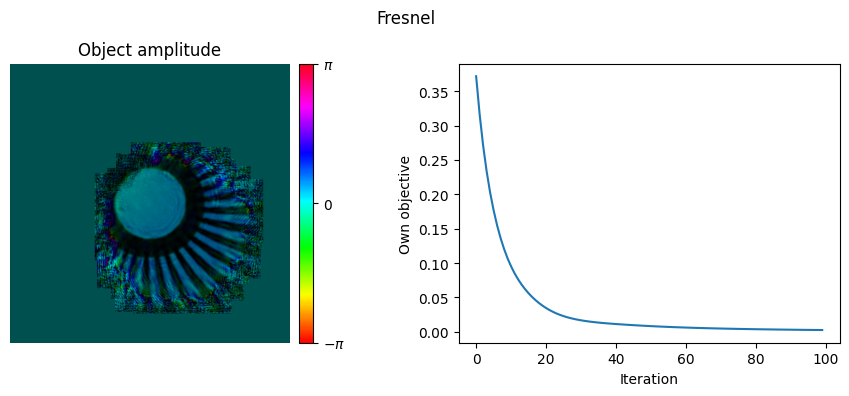

INFO:GPU:cupy and CUDA available, switching to GPU
INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ
GradientEngine: 100%|██████████| 100/100 [00:00<00:00, 103.75it/s, loss=0.000102]


ASP: 0.64767 -> 0.00010212


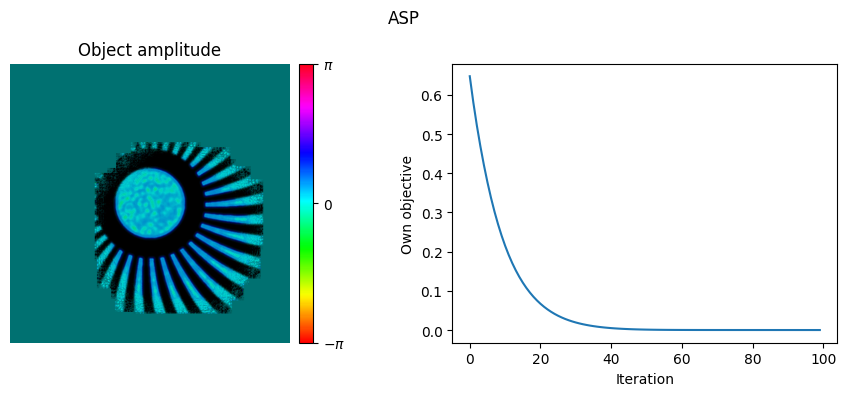

INFO:GPU:cupy and CUDA available, switching to GPU
INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ
GradientEngine: 100%|██████████| 100/100 [00:01<00:00, 89.45it/s, loss=0.0026]


scaledASP: 0.37247 -> 0.0025986


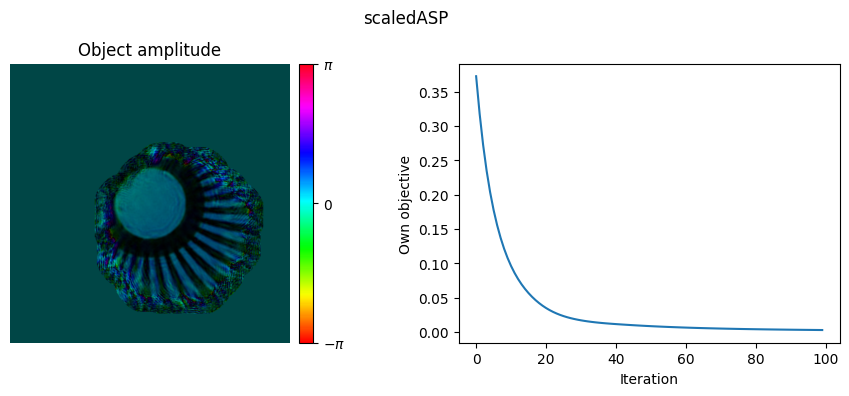

In [6]:
propagation_results = {"Fraunhofer": results["Amplitude"]}
for propagator in ("Fresnel", "ASP", "scaledASP"):
    propagation_data, propagation_initial, _ = simulate(propagator)
    engine = make_engine(propagation_data, propagation_initial)
    engine.reconstruct()
    propagation_results[propagator] = engine.reconstruction
    show_result(propagator, engine.reconstruction)